# Topic Analysis — Congressional Tweets and Bills

Descriptive analysis of the fitted topic space. Run `fit_topic_model.py` on the
server first; this notebook only reads its artifacts.

Two questions:
1. **What do legislators tweet about, and how does that change over time and by party?**
2. **Do tweet topics and bill topics overlap** — i.e. is there anything for the
   topic retriever to match on in the first place?

In [1]:
pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --force-reinstall --no-cache-dir     torch==2.6.0 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 195.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 192.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 327.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 161.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 124.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 99.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 185.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 160.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 129.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
pip install dotenv

  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SRC = Path.cwd() if (Path.cwd() / "pipeline").exists() else Path.cwd().parent
sys.path.insert(0, str(SRC))

from pipeline import config, topic_model, data_loader, vote_filters

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.figsize"] = (11, 5)

## 1. The topic space

In [5]:
space = topic_model.load_topic_space()
print(f"{len(space.topic_ids)} topics | embedding dim {space.centroids.shape[1]}")
print(json.dumps(space.meta, indent=2))

72 topics | embedding dim 768
{
  "embedding_model": "sentence-transformers/all-mpnet-base-v2",
  "n_fit_docs": 750000,
  "n_topics": 72,
  "fit_outlier_rate": 0.460532,
  "min_cluster_size": 200,
  "min_fit_words": 5,
  "seed": 42,
  "assign_min_similarity": 0.23505917191505432,
  "assign_min_sim_percentile": 5
}


In [6]:
# Topic sizes come from the full-corpus assignment written by fit_topic_model.py
tt = pd.read_parquet(config.TWEET_TOPICS_PARQUET)
tt["created_at"] = pd.to_datetime(tt["created_at"], utc=True, errors="coerce").dt.tz_localize(None)
print(f"{len(tt):,} tweets assigned | {tt['bioguide_id'].nunique()} legislators")

sizes = tt["topic"].value_counts().sort_values(ascending=False)
overview = pd.DataFrame({
    "topic": sizes.index,
    "n_tweets": sizes.values,
    "share_%": (sizes.values / len(tt) * 100).round(2),
})
overview["label"] = overview["topic"].map(lambda t: space.label(int(t)))
overview.head(30)

4,974,695 tweets assigned | 632 legislators


,topic,n_tweets,share_%,label
0,0,1792062,36.02,"today, act, care, health, day"
1,1,137847,2.77,"hurricane, storm, fema, disaster, stay"
2,26,90109,1.81,"id, citizenship, voter, america act, save"
3,37,87783,1.76,"real donald, donald trump, donald, real, trump"
4,58,87663,1.76,"st, patrick, day, happy, celebrate"
5,42,76284,1.53,"montana, mtpol, montanans, jon, matt"
6,61,75477,1.52,"ruth, justice, court, supreme court, supreme"
7,35,75397,1.52,"george, justice, murder, police, black"
8,17,72204,1.45,"nuclear, north, kim, weapons, sanctions"
9,14,71643,1.44,"criminal, justice, reform, bail, prison"


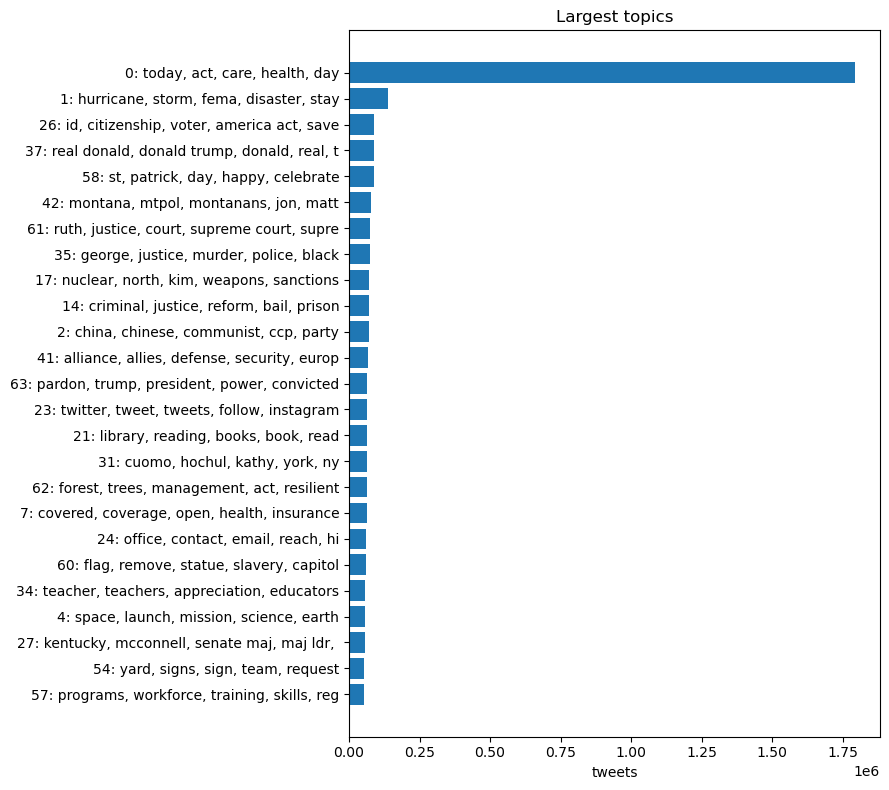

In [7]:
top = overview.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh([f"{r.topic}: {r.label[:42]}" for r in top.itertuples()], top["n_tweets"])
ax.set_xlabel("tweets"); ax.set_title("Largest topics")
plt.tight_layout(); plt.show()

### Representative tweets

Sanity-check that topics mean something before trusting any retrieval result.

In [8]:
corpus = topic_model.load_topic_corpus()
corpus = corpus.merge(tt[["id", "topic"]], on="id", how="inner")

def show_topic(tid, n=6):
    sub = corpus[corpus["topic"] == tid]
    print(f"--- topic {tid}: {space.label(int(tid))}  ({len(sub):,} tweets) ---")
    for t in sub["text"].head(n):
        print("  •", str(t)[:150])
    print()

for tid in overview["topic"].head(8):
    show_topic(int(tid))

--- topic 0: today, act, care, health, day  (1,792,062 tweets) ---
  • my legislation in honor of spc christian ward was passed to ensure no family member will bear this burden again.
  • potus – hardworking americans who have seen their paychecks and 401(k) plans vanish because of bidenflation don’t think the economy is “strong as hell
  • this is not compassion, this is cruelty. the biden administration allowing our southern border to be wide open with no restraints has created a disast
  • last week: california plans to mandate sales of electric cars\nthis week: don’t charge your electric car due to electricity shortages\n\nwhat’s going 
  • biden's student loan bailout is going to be paid for with your tax dollars.
  • spent the afternoon in marietta at a healthcare policy round table with af phq.

--- topic 1: hurricane, storm, fema, disaster, stay  (137,847 tweets) ---
  • my thoughts and prayers are with all the victims and those impacted by this tragic loss. rip jackie, emma, a

## 2. Topics over time

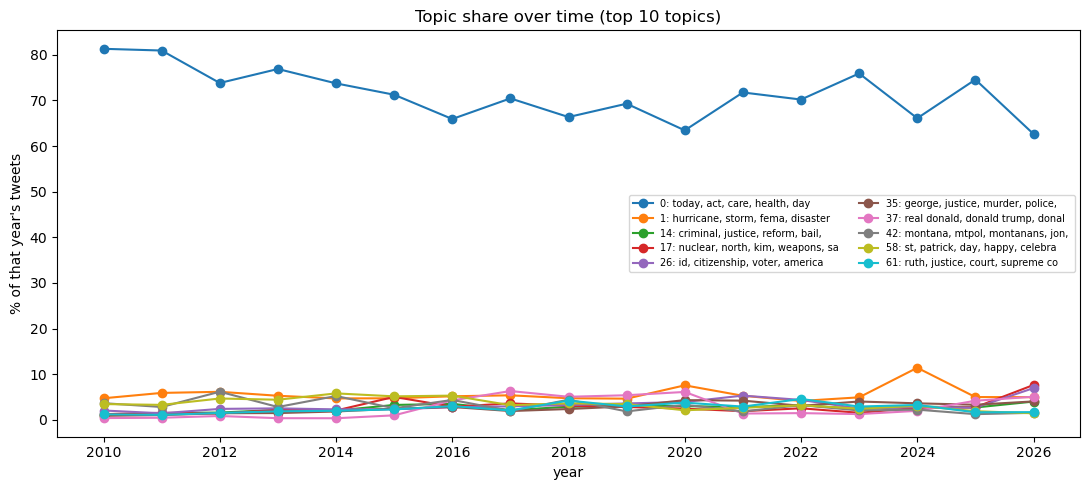

In [9]:
tt["year"] = tt["created_at"].dt.year
focus = overview["topic"].head(10).tolist()

pivot = (tt[tt["topic"].isin(focus)]
         .groupby(["year", "topic"]).size().unstack(fill_value=0))
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100   # share within year

fig, ax = plt.subplots()
for tid in pivot.columns:
    ax.plot(pivot.index, pivot[tid], marker="o", label=f"{tid}: {space.label(int(tid))[:32]}")
ax.set_ylabel("% of that year's tweets"); ax.set_xlabel("year")
ax.set_title("Topic share over time (top 10 topics)")
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

## 3. Topics by party

3,528,825 tweets matched to a party


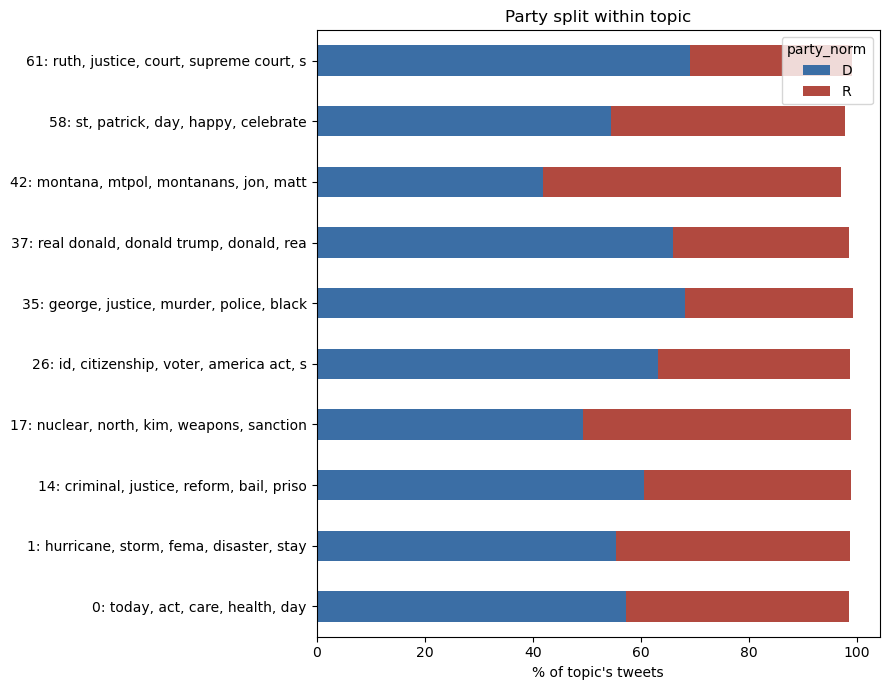

party_norm,D,I,R
"0: today, act, care, health, day",57.2,1.5,41.3
"1: hurricane, storm, fema, disaster, stay",55.4,1.2,43.4
"14: criminal, justice, reform, bail, priso",60.5,1.0,38.4
"17: nuclear, north, kim, weapons, sanction",49.2,1.1,49.7
"26: id, citizenship, voter, america act, s",63.1,1.2,35.7
"35: george, justice, murder, police, black",68.2,0.7,31.1
"37: real donald, donald trump, donald, rea",66.0,1.4,32.6
"42: montana, mtpol, montanans, jon, matt",42.0,3.0,55.0
"58: st, patrick, day, happy, celebrate",54.5,2.2,43.4
"61: ruth, justice, court, supreme court, s",69.1,0.9,30.0


In [10]:
votes = data_loader.load_votes("both")
party = (votes.sort_values("vote_date", ascending=False)
              .drop_duplicates("bioguide")[["bioguide", "party"]])
party["party_norm"] = party["party"].map(
    lambda p: "D" if str(p).upper().startswith("D") else ("R" if str(p).upper().startswith("R") else "I")
)

tp = tt.merge(party, left_on="bioguide_id", right_on="bioguide", how="inner")
print(f"{len(tp):,} tweets matched to a party")

by_party = (tp[tp["topic"].isin(focus)]
            .groupby(["topic", "party_norm"]).size().unstack(fill_value=0))
by_party = by_party.div(by_party.sum(axis=1), axis=0) * 100
by_party.index = [f"{t}: {space.label(int(t))[:38]}" for t in by_party.index]

by_party[["D", "R"]].plot(kind="barh", stacked=True, figsize=(9, 7),
                          color={"D": "#3b6ea5", "R": "#b1493f"})
plt.xlabel("% of topic's tweets"); plt.title("Party split within topic")
plt.tight_layout(); plt.show()
by_party.round(1)

## 4. Do tweet topics and bill topics overlap?

The retriever can only work where legislators tweet about things bills are
about. This projects every vote into the tweet topic space and compares the
two distributions.

In [11]:
if config.DROP_NOMINATION_VOTES:
    votes = vote_filters.filter_nominations(votes)

bills = votes.drop_duplicates("vote_id")[
    ["vote_id", "chamber", "congress", "bill_title", "bill_summary", "question"]
].copy()
print(f"{len(bills):,} unique votes")
print(f"  with a summary: {(bills['bill_summary'].astype(str).str.strip() != '').mean()*100:.1f}%")

# Embed each vote's query text and take its dominant topic.
query_texts, owner = [], []
for r in bills.itertuples():
    for chunk in topic_model.build_vote_query_texts(r.bill_title, r.bill_summary, r.question):
        query_texts.append(chunk); owner.append(r.vote_id)

emb = topic_model.encode(query_texts, show_progress=True)
distr = space.topic_distribution(emb)

qdf = pd.DataFrame({"vote_id": owner})
pooled = pd.DataFrame(distr).groupby(qdf["vote_id"]).max()
pooled = pooled.div(pooled.sum(axis=1), axis=0)
bill_topic = pd.Series(space.topic_ids[pooled.values.argmax(axis=1)], index=pooled.index, name="topic")
bills = bills.merge(bill_topic, left_on="vote_id", right_index=True, how="left")
bills["topic_label"] = bills["topic"].map(lambda t: space.label(int(t)) if pd.notna(t) else "")
bills[["vote_id", "bill_title", "topic", "topic_label"]].head(15)

3,457 unique votes
  with a summary: 99.5%


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

,vote_id,bill_title,topic,topic_label
0,house_110_1st_15,Implementing the 9/11Commission Recommendations Act,67,"firefighters, grant, departments, equipment, grants"
427,house_110_1st_18,Fair Minimum Wage Act,44,"restaurants, restaurant, fund, relief, businesses"
858,house_110_1st_20,Stem Cell Research Enhancement Act,48,"manufacturing, science, chip, act, supply"
1285,house_110_1st_23,Medicare Prescription Drug Price Negotiation Act,20,"cap, cost, month, costs, price"
1710,senate_110_1_12,Motion to Invoke Cloture on the Reid Amdt. No. 4 to S.1,0,"today, act, care, health, day"
1807,house_110_1st_28,To provide for an additional temporary extension of programs under the Small Business ...,56,"disaster, loans, sb, small, apply"
1809,house_110_1st_32,College Student Relief Act,56,"disaster, loans, sb, small, apply"
2649,senate_110_1_16,Motion to Invoke Cloture on the Reid Amdt No. 3 To S.1,0,"today, act, care, health, day"
2746,house_110_1st_40,Creating Long-Term Energy Alternatives for the Nation Act,53,"nuclear, energy, power, plant, reliable"
3173,senate_110_1_19,S.1 As Amended,0,"today, act, care, health, day"


In [12]:
tweet_share = tt["topic"].value_counts(normalize=True) * 100
bill_share  = bills["topic"].value_counts(normalize=True) * 100

cmp = pd.DataFrame({"tweet_%": tweet_share, "bill_%": bill_share}).fillna(0)
cmp["label"] = [space.label(int(t)) for t in cmp.index]
cmp["gap"] = cmp["tweet_%"] - cmp["bill_%"]

print("Topics legislators TWEET about far more than they VOTE on:")
display(cmp.sort_values("gap", ascending=False).head(12).round(2))
print("\nTopics they VOTE on far more than they TWEET about:")
display(cmp.sort_values("gap").head(12).round(2))

Topics legislators TWEET about far more than they VOTE on:


,tweet_%,bill_%,label,gap
topic,,,,
0,36.02,22.42,"today, act, care, health, day",13.61
37,1.76,0.00,"real donald, donald trump, donald, real, trump",1.76
58,1.76,0.00,"st, patrick, day, happy, celebrate",1.76
35,1.52,0.06,"george, justice, murder, police, black",1.46
42,1.53,0.17,"montana, mtpol, montanans, jon, matt",1.36
61,1.52,0.20,"ruth, justice, court, supreme court, supreme",1.31
31,1.28,0.00,"cuomo, hochul, kathy, york, ny",1.28
23,1.31,0.03,"twitter, tweet, tweets, follow, instagram",1.28
24,1.21,0.00,"office, contact, email, reach, hi",1.21



Topics they VOTE on far more than they TWEET about:


,tweet_%,bill_%,label,gap
topic,,,,
62,1.28,10.41,"forest, trees, management, act, resilient",-9.13
14,1.44,7.00,"criminal, justice, reform, bail, prison",-5.56
56,0.51,5.67,"disaster, loans, sb, small, apply",-5.16
67,0.88,5.35,"firefighters, grant, departments, equipment, grants",-4.47
5,0.47,4.80,"usps, mail, service, post, delivery",-4.33
53,1.04,3.91,"nuclear, energy, power, plant, reliable",-2.86
51,0.53,3.24,"ex, bank, im, jobs, export",-2.71
7,1.27,3.27,"covered, coverage, open, health, insurance",-2.00
28,0.66,2.55,"file, tax, filing, irs, taxes",-1.89


Topics present in BOTH tweets and bills: 58/73
Share of bills in a topic that tweets also cover: 100.0%


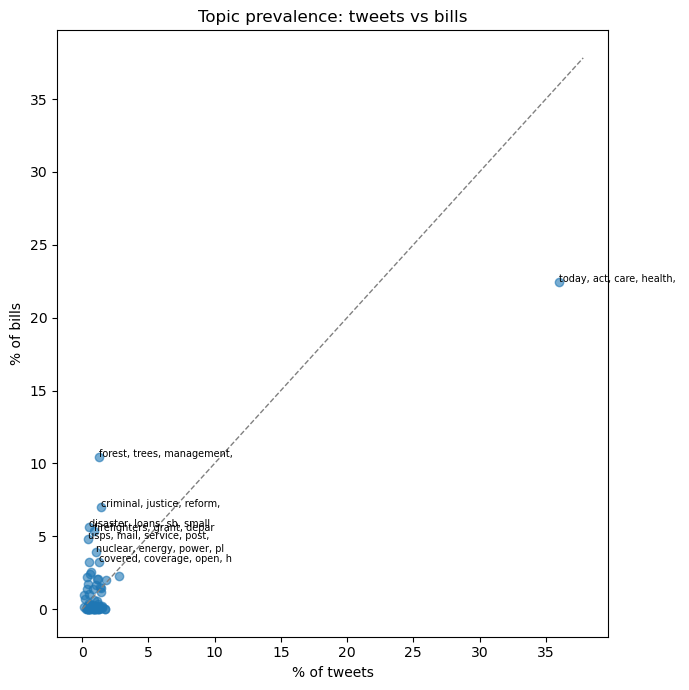

In [13]:
covered = cmp[(cmp["tweet_%"] > 0) & (cmp["bill_%"] > 0)]
print(f"Topics present in BOTH tweets and bills: {len(covered)}/{len(cmp)}")
print(f"Share of bills in a topic that tweets also cover: {covered['bill_%'].sum():.1f}%")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cmp["tweet_%"], cmp["bill_%"], alpha=0.6)
lim = max(cmp["tweet_%"].max(), cmp["bill_%"].max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="grey", lw=1)
ax.set_xlabel("% of tweets"); ax.set_ylabel("% of bills")
ax.set_title("Topic prevalence: tweets vs bills")
for r in cmp.sort_values("bill_%", ascending=False).head(8).itertuples():
    ax.annotate(str(r.label)[:26], (r._1, r._2), fontsize=7)
plt.tight_layout(); plt.show()

## 5. Retrieval diagnostics

The number that matters: the LLM retriever returned zero relevant tweets for
**92.8%** of candidates. Run `rerank_cache.py --sweep` against a sample cache
to pick a threshold, then compare here.

```bash
python rerank_cache.py --cache data/sample_cache.pkl --sweep
```

In [14]:
# Compare zero-relevant rates across prediction runs.
import glob
rows = []
for f in sorted(glob.glob(str(SRC / "results" / "predictions*.csv"))) + \
         sorted(glob.glob(str(SRC / "old" / "predictions*.csv"))):
    d = pd.read_csv(f, low_memory=False)
    if "n_tweets_used" not in d.columns:
        continue
    ok = d[d["predicted_label"].isin(["Yea", "Nay"])] if "predicted_label" in d else d
    rows.append({
        "run": Path(f).name,
        "n": len(d),
        "retrieval": d["retrieval_method"].iloc[0] if "retrieval_method" in d.columns else "llm",
        "zero_relevant_%": round((d["n_tweets_used"] == 0).mean() * 100, 1),
        "median_used": d["n_tweets_used"].median(),
        "accuracy_%": round((ok["true_label"] == ok["predicted_label"]).mean() * 100, 1)
                      if "true_label" in ok else np.nan,
    })
pd.DataFrame(rows)

,run,n,retrieval,zero_relevant_%,median_used,accuracy_%
0,predictions.csv,10664,llm,92.8,0.0,83.6
1,predictions_full.csv,10000,llm,0.0,6.0,86.9
2,predictions_full_random.csv,10100,llm,90.4,0.0,83.2
3,predictions_full_stratified.csv,9272,llm,0.0,6.0,86.8
4,predictions_no_context.csv,10000,llm,0.0,6.0,77.6
5,predictions_no_context_random.csv,484,llm,90.7,0.0,68.6
6,predictions_no_context_stratified.csv,9272,llm,0.0,6.0,76.3
7,predictions_no_tweets.csv,10000,llm,100.0,0.0,86.1
8,predictions_no_tweets_stratified.csv,9272,llm,100.0,0.0,85.6
9,predictions_no_voting_random.csv,10100,llm,90.4,0.0,79.6
